# Breakout Prediction with LightGBM

This notebook documents a supervised learning pipeline for predicting cryptocurrency breakout events at three horizons: 1 hour, 4 hours, and 24 hours. The pipeline first loads the feature table from `breakout_features.parquet` and applies several data-cleaning rules. Stablecoins, leveraged tokens, short instruments, columns that could introduce leakage, and groups with too few observations are excluded. The `price_position_in_zone` variable is clipped to [0, 1] and missing entries are imputed; a separate indicator records whether the original zone was degenerate. A chronological development/test split is then constructed. Within the development period, `GroupKFold` is used on `(ticker, level_id)` to obtain out-of-fold estimates. One LightGBM classifier is trained per horizon. The evaluation covers ROC AUC, PR AUC, precision at several top-k fractions, Brier score, and feature importance. Models, importance tables, metrics, and configuration are saved to `/artifacts/`.

In [50]:
from pathlib import Path
import json
import re
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_STATE = 42
DATA_PATH = './../dataset/breakout_features.parquet'
OUTPUT_DIR = Path.cwd().parent / 'artifacts'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TARGETS = ['breakout_1h', 'breakout_4h', 'breakout_24h']
N_SPLITS = 5
TOP_K = [0.01, 0.02, 0.05, 0.10, 0.20]

print(f'Output directory: {OUTPUT_DIR.resolve()}')
print(f'Targets: {TARGETS}')

Output directory: C:\Users\andfi\Documents\Study\CM3070-Final-Project\FinancAIBot\artifacts
Targets: ['breakout_1h', 'breakout_4h', 'breakout_24h']


In [51]:
df = pd.read_parquet(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

required = {'ticker', 'level_id', 'prediction_time', *TARGETS}
missing = required - set(df.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')

df['prediction_time'] = pd.to_datetime(df['prediction_time'], utc=True, errors='coerce')
df = df.dropna(subset=['ticker', 'level_id', 'prediction_time']).copy()
df['ticker'] = df['ticker'].astype(str).str.upper()

stable_symbols = {
    'USDC', 'USDT', 'TUSD', 'BUSD', 'FDUSD', 'DAI', 'USDP', 'PAX', 'EUR',
    'GBP', 'USDE', 'USDS', 'UST', 'USTC', 'FRAX', 'PYUSD', 'EURC',
}
leveraged_re = re.compile(r'(UP|DOWN|BULL|BEAR)(USDT|USDC|BUSD)?$')
quote_suffix_re = re.compile(r'(USDT|USDC|BUSD)$')
def is_excluded_ticker(ticker):
    base = quote_suffix_re.sub('', ticker)
    return ticker in stable_symbols or base in stable_symbols or bool(leveraged_re.search(ticker))

before = len(df)
df = df.loc[~df['ticker'].map(is_excluded_ticker)].copy()
counts = df['ticker'].value_counts()
valid_tickers = counts[counts >= 50].index
df = df.loc[df['ticker'].isin(valid_tickers)].copy()
print(f'After ticker filters: {len(df):,} rows, {df.ticker.nunique():,} tickers (removed {before - len(df):,} rows)')
print('Stable/leveraged check:', [ticker for ticker in ['USDCUSDT', 'BUSDUSDT', 'GBPUSDT', 'PAXGUSDT'] if ticker in set(df['ticker'])])

df['level_key'] = df['ticker'].astype(str) + '::' + df['level_id'].astype(str)
df = df.sort_values(['prediction_time', 'ticker', 'level_id']).reset_index(drop=True)
for column in ['touch_times', 'time_since_last_touch']:
    if column in df.columns:
        df = df.drop(columns=column)
if 'price_position_in_zone' in df.columns:
    raw_position = pd.to_numeric(df['price_position_in_zone'], errors='coerce')
    df['is_degenerate_zone'] = raw_position.isna().astype('int8')
    df['price_position_in_zone'] = raw_position.clip(0.0, 1.0).fillna(0.5)
else:
    df['is_degenerate_zone'] = 0

print('Groups:', df['level_key'].nunique())
print('Target availability:', df[TARGETS].notna().mean().round(3).to_dict())

Loaded: 648,646 rows x 55 columns
After ticker filters: 574,223 rows, 397 tickers (removed 74,423 rows)
Stable/leveraged check: ['PAXGUSDT']
Groups: 173087
Target availability: {'breakout_1h': 1.0, 'breakout_4h': 1.0, 'breakout_24h': 1.0}


## Exploratory Data Analysis

Before modelling, the dataset is inspected for size, time coverage, target prevalence, ticker coverage, missing values, and the distribution of touch counts. The first modelling pass intentionally focuses on the ten symbols with the most valid snapshots. This reduces cross-symbol averaging and makes the results easier to interpret.

Rows: 574,223
Columns: 55
Time range: 2017-08-19 11:51:00+00:00 to 2025-12-30 23:53:00+00:00
Tickers: 397
Unique level groups: 173087

Target prevalence and availability:


,rows,positive_count,positive_rate
breakout_1h,574223,66970,0.1166
breakout_4h,574223,152202,0.2651
breakout_24h,574223,337558,0.5879



Rows and groups per ticker:


,rows,level_groups
ticker,,
BTTCUSDT,7078,1277
PAXGUSDT,3938,1078
BNBUSDT,3620,1085
LTCUSDT,3475,1054
XRPUSDT,3291,1005
XLMUSDT,3269,993
ETHUSDT,3215,978
ADAUSDT,3184,975
DOGEUSDT,2947,888



Missing-value share:


,missing_share
volume_ratio_24h,0.000371
quote_volume_ratio_24h,0.000371
return_24h,0.000369
btc_return_24h,0.000369
btc_volume_ratio_24h,0.000369
btc_quote_volume_ratio_24h,0.000369
range_24h,0.000367
volume_ratio_1h,0.000334
quote_volume_ratio_1h,0.000334
return_12h,0.000158



Touch-count distribution:


,count,mean,std,min,50%,75%,90%,95%,99%,max
touch_count,574223.0,2.245678,1.199718,1.0,2.0,3.0,3.0,4.0,5.0,44.0


,rows
touch_count,
1,173087
2,173045
3,172971
4,39824
5,9881
6,2851
7,991
8,452
9,256


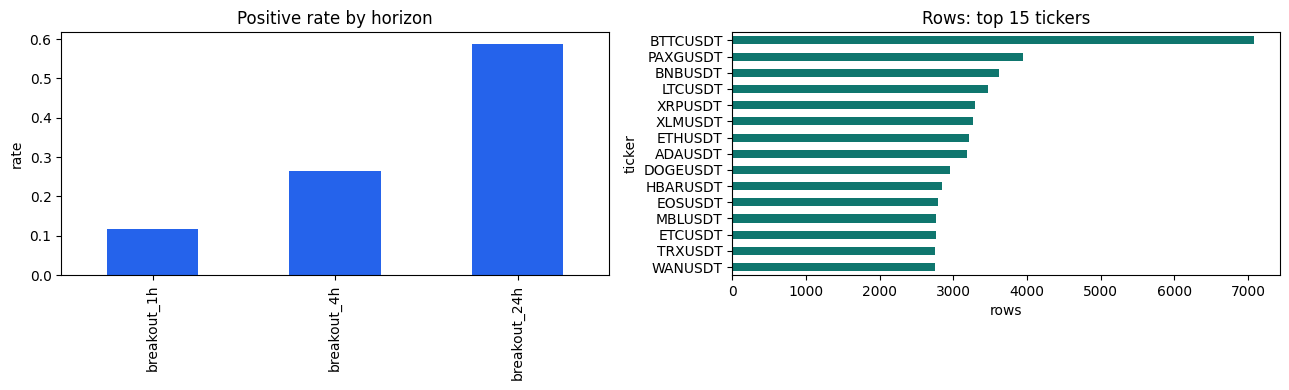

In [52]:
print('Rows:', f'{len(df):,}')
print('Columns:', len(df.columns))
print('Time range:', df['prediction_time'].min(), 'to', df['prediction_time'].max())
print('Tickers:', df['ticker'].nunique())
print('Unique level groups:', df['level_key'].nunique())

print('\nTarget prevalence and availability:')
target_summary = pd.DataFrame({
    'rows': df[TARGETS].notna().sum(),
    'positive_count': df[TARGETS].eq(1).sum(),
    'positive_rate': df[TARGETS].mean(),
})
display(target_summary.round(4))

print('\nRows and groups per ticker:')
ticker_summary = (
    df.groupby('ticker')
    .agg(rows=('level_key', 'size'), level_groups=('level_key', 'nunique'))
    .sort_values('rows', ascending=False)
)
display(ticker_summary.head(20))

print('\nMissing-value share:')
display(df.isna().mean().sort_values(ascending=False).head(20).to_frame('missing_share'))

if 'touch_count' in df.columns:
    print('\nTouch-count distribution:')
    display(df['touch_count'].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame().T)
    display(df['touch_count'].value_counts().sort_index().head(20).to_frame('rows'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
target_summary['positive_rate'].plot(kind='bar', ax=axes[0], color='#2563eb', title='Positive rate by horizon')
axes[0].set_ylabel('rate')
ticker_summary.head(15)['rows'].sort_values().plot(kind='barh', ax=axes[1], color='#0f766e', title='Rows: top 15 tickers')
axes[1].set_xlabel('rows')
plt.tight_layout()
plt.show()

In [53]:
FOCUS_TICKERS = ticker_summary.head(10).index.tolist()
model_df = df.loc[df['ticker'].isin(FOCUS_TICKERS)].copy()
print('Focus tickers:', FOCUS_TICKERS)
print(f'Focused rows: {len(model_df):,} ({len(model_df) / max(len(df), 1):.1%} of filtered data)')
print(f'Focused level groups: {model_df["level_key"].nunique():,}')
print('Focused target prevalence:')
display(model_df[TARGETS].mean().round(4).to_frame('positive_rate'))

Focus tickers: ['BTTCUSDT', 'PAXGUSDT', 'BNBUSDT', 'LTCUSDT', 'XRPUSDT', 'XLMUSDT', 'ETHUSDT', 'ADAUSDT', 'DOGEUSDT', 'HBARUSDT']
Focused rows: 36,866 (6.4% of filtered data)
Focused level groups: 10,185
Focused target prevalence:


,positive_rate
breakout_1h,0.0915
breakout_4h,0.2239
breakout_24h,0.5458


In [54]:
# Construct numeric features for the ten-ticker subsample.
model_df = model_df.sort_values(['prediction_time', 'ticker', 'level_id']).reset_index(drop=True)
if 'level_type' in model_df.columns:
    level_type_mapping_train = {'resistance': 0, 'support': 1, 'missing': -1}
    model_df['level_type'] = model_df['level_type'].fillna('missing').astype(str).map(level_type_mapping_train).fillna(-1).astype('int16')

excluded_features = {
    'ticker', 'level_id', 'level_key', 'prediction_time',
    'first_touch_time', 'last_touch_time', *TARGETS,
    '_time_bucket', '_slice_number', '_day_in_slice', '_slice_window',
}
feature_cols = [
    column for column in model_df.columns
    if column not in excluded_features and pd.api.types.is_numeric_dtype(model_df[column])
]
if not feature_cols:
    raise ValueError('No numeric model features remain after exclusions.')
if {'level_id', 'ticker', 'touch_times', 'time_since_last_touch'} & set(feature_cols):
    raise AssertionError('A forbidden leakage/object column entered the feature set.')
if any(column.startswith('_') for column in feature_cols):
    raise AssertionError('A temporary split column entered the feature set.')

# Retain the cleaned subsample for the fixed chronological split.
prepared_df = model_df.copy()
time_values = model_df['prediction_time'].sort_values()
train_cutoff = time_values.quantile(0.70)
val_cutoff = time_values.quantile(0.85)

def time_bucket(timestamp):
    if timestamp <= train_cutoff:
        return 'train'
    if timestamp <= val_cutoff:
        return 'val'
    return 'test'

model_df['_time_bucket'] = model_df['prediction_time'].map(time_bucket)
group_bucket_count = model_df.groupby('level_key')['_time_bucket'].nunique()
clean_groups = group_bucket_count[group_bucket_count == 1].index
model_df = model_df.loc[model_df['level_key'].isin(clean_groups)].copy()

dev = model_df.loc[model_df['_time_bucket'].isin(['train', 'val'])].copy()
test = model_df.loc[model_df['_time_bucket'] == 'test'].copy()
train = dev.loc[dev['_time_bucket'] == 'train'].copy()
val = dev.loc[dev['_time_bucket'] == 'val'].copy()

assert train['prediction_time'].max() <= val['prediction_time'].min()
assert val['prediction_time'].max() <= test['prediction_time'].min()
assert not set(train.level_key) & set(val.level_key)
assert not set(dev.level_key) & set(test.level_key)

print(f'Fixed chronological split: train={len(train):,}, validation={len(val):,}, test={len(test):,}')
print(f'Cutoffs: train <= {train_cutoff}, validation <= {val_cutoff}')
print(f'Dropped boundary groups: {group_bucket_count.size - len(clean_groups):,}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

Fixed chronological split: train=25,555, validation=5,239, test=5,326
Cutoffs: train <= 2024-01-14 20:02:00+00:00, validation <= 2024-12-07 04:10:00+00:00
Dropped boundary groups: 172
Features (45): ['level_type', 'center', 'zone_low', 'zone_high', 'touch_count', 'recent_touch_count', 'level_age_bars', 'touch_density', 'recent_touch_density', 'zone_width_pct', 'zone_width_atr', 'price_position_in_zone', 'distance_to_level_pct', 'distance_to_level_atr', 'return_1h', 'return_4h', 'return_12h', 'return_24h', 'range_1h', 'range_4h', 'range_24h', 'atr_pct', 'volume_ratio_1h', 'volume_ratio_4h', 'volume_ratio_24h', 'quote_volume_ratio_1h', 'quote_volume_ratio_4h', 'quote_volume_ratio_24h', 'distance_change_1h', 'distance_change_4h', 'approach_velocity_1h', 'approach_velocity_4h', 'btc_return_1h', 'btc_return_4h', 'btc_return_24h', 'btc_volume_ratio_1h', 'btc_volume_ratio_4h', 'btc_volume_ratio_24h', 'btc_quote_volume_ratio_1h', 'btc_quote_volume_ratio_4h', 'btc_quote_volume_ratio_24h', 'btc_

In [55]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def top_k_details(y_true, y_prob, fraction):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    n_selected = max(1, int(np.ceil(len(y_true) * fraction)))
    top_indices = np.argsort(-y_prob)[:n_selected]
    positives_selected = int(y_true[top_indices].sum())
    total_positives = int(y_true.sum())
    return {
        'n_selected': n_selected,
        'positives_selected': positives_selected,
        'precision': float(positives_selected / n_selected),
        'recall': float(positives_selected / max(total_positives, 1)),
    }


def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    metrics = {
        'n_rows': len(y_true),
        'positive_count': int(y_true.sum()),
        'positive_rate': float(y_true.mean()),
        'threshold': threshold,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'brier': float(brier_score_loss(y_true, y_prob)),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }
    if len(np.unique(y_true)) == 2:
        metrics['roc_auc'] = float(roc_auc_score(y_true, y_prob))
        metrics['pr_auc'] = float(average_precision_score(y_true, y_prob))
    else:
        metrics['roc_auc'] = np.nan
        metrics['pr_auc'] = np.nan
    for fraction in TOP_K:
        details = top_k_details(y_true, y_prob, fraction)
        suffix = f'{int(fraction * 100)}pct'
        metrics[f'precision_at_{suffix}'] = details['precision']
        metrics[f'recall_at_{suffix}'] = details['recall']
        metrics[f'n_top_{suffix}'] = details['n_selected']
    return metrics


def make_model(**params):
    defaults = {
        'objective': 'binary',
        'n_estimators': 600,
        'learning_rate': 0.03,
        'num_leaves': 31,
        'max_depth': -1,
        'min_child_samples': 80,
        'subsample': 0.85,
        'colsample_bytree': 0.85,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbosity': -1,
    }
    defaults.update(params)
    return lgb.LGBMClassifier(**defaults)

In [56]:
import time
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GroupKFold

all_metrics = []
all_importances = {}
trained_models = {}
grid_results = {}

param_distributions = {
    'num_leaves': [7, 15, 31],
    'min_child_samples': [20, 50, 100],
    'learning_rate': [0.01, 0.03, 0.07],
    'n_estimators': [400, 800],
    'subsample': [0.7, 0.85],
    'colsample_bytree': [0.7, 0.85],
    'reg_alpha': [0.0, 0.1],
    'reg_lambda': [0.5, 1.0],
    'scale_pos_weight': [1, 2, 5, 10],
}

N_ITER = 150 
N_JOBS_SEARCH = -1
N_JOBS_MODEL = 1

for target in TARGETS:
    print(f'\n===== {target} =====')
    t0 = time.time()

    train_target = train.dropna(subset=[target]).copy()
    val_target = val.dropna(subset=[target]).copy()
    test_target = test.dropna(subset=[target]).copy()
    for frame in (train_target, val_target, test_target):
        frame[target] = pd.to_numeric(frame[target], errors='coerce').astype('int8')

    X_train = train_target[feature_cols]
    y_train = train_target[target]
    groups = train_target['level_key']
    n_splits = min(N_SPLITS, groups.nunique())
    grouped_cv = GroupKFold(n_splits=n_splits)

    search = RandomizedSearchCV(
        estimator=make_model(n_jobs=N_JOBS_MODEL),
        param_distributions=param_distributions,
        n_iter=N_ITER,
        scoring='average_precision',
        cv=grouped_cv,
        n_jobs=N_JOBS_SEARCH,
        refit=True,
        return_train_score=True,
        random_state=RANDOM_STATE,
        verbose=1,
    )
    search.fit(X_train, y_train, groups=groups)

    final_model = search.best_estimator_
    grid_results[target] = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
    trained_models[target] = final_model

    elapsed = time.time() - t0
    print(f'Best parameters: {search.best_params_}')
    print(f'Best grouped CV PR AUC: {search.best_score_:.4f}')
    print(f'Time: {elapsed/60:.1f} min')

    # Overfitting diagnostic
    best_idx = search.best_index_
    train_score = search.cv_results_['mean_train_score'][best_idx]
    test_score = search.cv_results_['mean_test_score'][best_idx]
    print(f'Train PR AUC: {train_score:.4f} | Val PR AUC: {test_score:.4f} | Gap: {train_score - test_score:.4f}')

    # Evaluation on validation and test sets
    for split_name, frame in [('validation', val_target), ('test', test_target)]:
        y_split = frame[target].to_numpy()
        probability = final_model.predict_proba(frame[feature_cols])[:, 1]
        split_metrics = evaluate_predictions(y_split, probability, threshold=0.5)
        split_metrics.update({'target': target, 'split': split_name})
        all_metrics.append(split_metrics)
        print(f'{split_name} metrics:')
        print(classification_report(y_split, (probability >= 0.5).astype(int), zero_division=0))
        print('Confusion matrix:\n', np.asarray(split_metrics['confusion_matrix']))

    # Feature importance and model persistence
    importance = pd.DataFrame({
        'feature': feature_cols,
        'gain': final_model.booster_.feature_importance(importance_type='gain'),
        'split': final_model.booster_.feature_importance(importance_type='split'),
    }).sort_values('gain', ascending=False)
    importance['gain_share'] = importance['gain'] / max(importance['gain'].sum(), 1e-12)
    all_importances[target] = importance
    display(importance.head(10))

    grid_results[target].to_csv(OUTPUT_DIR / f'grid_search_{target}.csv', index=False)
    importance.to_csv(OUTPUT_DIR / f'feature_importance_{target}.csv', index=False)
    joblib.dump(final_model, OUTPUT_DIR / f'lightgbm_{target}.joblib')

metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv(OUTPUT_DIR / 'metrics.csv', index=False)
display(metrics_df[['target', 'split', 'roc_auc', 'pr_auc', 'accuracy',
                     'precision', 'recall', 'f1', 'brier',
                     'precision_at_1pct', 'recall_at_1pct']].round(4))


===== breakout_1h =====
Fitting 5 folds for each of 150 candidates, totalling 750 fits
Best parameters: {'subsample': 0.85, 'scale_pos_weight': 2, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'num_leaves': 7, 'n_estimators': 800, 'min_child_samples': 20, 'learning_rate': 0.03, 'colsample_bytree': 0.85}
Best grouped CV PR AUC: 0.2103
Time: 12.6 min
Train PR AUC: 0.4962 | Val PR AUC: 0.2103 | Gap: 0.2859
validation metrics:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      4818
           1       0.29      0.02      0.04       421

    accuracy                           0.92      5239
   macro avg       0.60      0.51      0.50      5239
weighted avg       0.87      0.92      0.88      5239

Confusion matrix:
 [[4798   20]
 [ 413    8]]
test metrics:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      4947
           1       0.25      0.02      0.03       379

    accuracy                  

,feature,gain,split,gain_share
4,touch_count,15437.089993,127,0.154832
2,zone_low,5913.798713,91,0.059315
21,atr_pct,5786.520698,306,0.058038
3,zone_high,5701.812098,39,0.057188
28,distance_change_1h,5131.868696,167,0.051472
11,price_position_in_zone,3297.639196,128,0.033075
29,distance_change_4h,2841.439590,154,0.028499
22,volume_ratio_1h,2453.084547,110,0.024604
13,distance_to_level_atr,2374.558530,127,0.023816
15,return_4h,2271.653976,128,0.022784



===== breakout_4h =====
Fitting 5 folds for each of 150 candidates, totalling 750 fits
Best parameters: {'subsample': 0.85, 'scale_pos_weight': 2, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'num_leaves': 15, 'n_estimators': 800, 'min_child_samples': 20, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best grouped CV PR AUC: 0.4269
Time: 12.7 min
Train PR AUC: 0.5707 | Val PR AUC: 0.4269 | Gap: 0.1438
validation metrics:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      4116
           1       0.46      0.54      0.50      1123

    accuracy                           0.76      5239
   macro avg       0.66      0.68      0.67      5239
weighted avg       0.78      0.76      0.77      5239

Confusion matrix:
 [[3393  723]
 [ 512  611]]
test metrics:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      4379
           1       0.45      0.59      0.51       947

    accuracy                  

,feature,gain,split,gain_share
4,touch_count,90908.385498,390,0.238547
21,atr_pct,39042.934239,1166,0.102450
3,zone_high,36674.305371,163,0.096235
43,is_confirmation_touch,19135.902833,33,0.050213
10,zone_width_atr,18816.167378,303,0.049374
2,zone_low,15551.888031,182,0.040809
1,center,13404.848726,324,0.035175
6,level_age_bars,9316.525399,286,0.024447
29,distance_change_4h,9109.909033,277,0.023905
13,distance_to_level_atr,8206.439946,177,0.021534



===== breakout_24h =====
Fitting 5 folds for each of 150 candidates, totalling 750 fits
Best parameters: {'subsample': 0.7, 'scale_pos_weight': 1, 'reg_lambda': 0.5, 'reg_alpha': 0.0, 'num_leaves': 7, 'n_estimators': 400, 'min_child_samples': 100, 'learning_rate': 0.03, 'colsample_bytree': 0.85}
Best grouped CV PR AUC: 0.7239
Time: 11.9 min
Train PR AUC: 0.7685 | Val PR AUC: 0.7239 | Gap: 0.0445
validation metrics:
              precision    recall  f1-score   support

           0       0.60      0.54      0.56      2380
           1       0.64      0.70      0.67      2859

    accuracy                           0.62      5239
   macro avg       0.62      0.62      0.62      5239
weighted avg       0.62      0.62      0.62      5239

Confusion matrix:
 [[1276 1104]
 [ 861 1998]]
test metrics:
              precision    recall  f1-score   support

           0       0.70      0.67      0.69      2793
           1       0.65      0.68      0.67      2533

    accuracy                 

,feature,gain,split,gain_share
21,atr_pct,13188.342577,246,0.201736
4,touch_count,12281.200029,142,0.187860
10,zone_width_atr,8601.286370,58,0.131570
3,zone_high,3164.121819,39,0.048400
1,center,2380.465877,75,0.036413
9,zone_width_pct,2337.786509,47,0.035760
18,range_1h,2211.188595,56,0.033824
6,level_age_bars,2027.655554,96,0.031016
20,range_24h,1775.639538,162,0.027161
7,touch_density,1409.618029,58,0.021562


,target,split,roc_auc,pr_auc,accuracy,precision,recall,f1,brier,precision_at_1pct,recall_at_1pct
0,breakout_1h,validation,0.7716,0.2108,0.9174,0.2857,0.0190,0.0356,0.0738,0.3396,0.0428
1,breakout_1h,test,0.8086,0.2132,0.9262,0.2500,0.0185,0.0344,0.0654,0.2407,0.0343
2,breakout_4h,validation,0.7512,0.4256,0.7643,0.4580,0.5441,0.4974,0.1584,0.5849,0.0276
3,breakout_4h,test,0.7942,0.4205,0.7993,0.4505,0.5861,0.5094,0.1366,0.5000,0.0285
4,breakout_24h,validation,0.6728,0.7036,0.6249,0.6441,0.6988,0.6704,0.2253,0.8679,0.0161
5,breakout_24h,test,0.7342,0.6899,0.6757,0.6529,0.6794,0.6659,0.2090,0.9074,0.0193


## Probability Calibration

The raw LightGBM probabilities are not guaranteed to be well calibrated, especially for the 1-hour horizon where the event rate is low. Isotonic regression is therefore fitted on top of each trained model using the validation set. The base learner is wrapped in `FrozenEstimator`, so only the calibration mapping is learned and the underlying model is not retrained.

The aim is to make predicted probabilities interpretable: a threshold of 0.5 should then correspond approximately to a 50% event rate. Since isotonic regression is a monotonic transformation, it does not change the ranking of predictions, and PR AUC is therefore unaffected. The Brier score, however, is expected to improve for the 1-hour and 4-hour horizons, where the raw probabilities tend to be miscalibrated. For the 24-hour horizon the raw model is already reasonably calibrated, so the gain is small.

In [57]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss

calibrated_models = {}
calibration_rows = []

for target in TARGETS:
    # Prepare validation and test frames for this horizon
    train_t = train.dropna(subset=[target]).copy()
    val_t = val.dropna(subset=[target]).copy()
    test_t = test.dropna(subset=[target]).copy()
    for frame in (train_t, val_t, test_t):
        frame[target] = frame[target].astype(int)

    # Wrap the already-trained booster so that
    # CalibratedClassifierCV does not retrain it.
    base = trained_models[target]
    calibrated = CalibratedClassifierCV(FrozenEstimator(base), method='isotonic')
    calibrated.fit(val_t[feature_cols], val_t[target])
    calibrated_models[target] = calibrated

    # Compare raw vs calibrated probabilities on validation and test
    for split_name, frame in [('validation', val_t), ('test', test_t)]:
        y = frame[target].to_numpy()
        p_raw = base.predict_proba(frame[feature_cols])[:, 1]
        p_cal = calibrated.predict_proba(frame[feature_cols])[:, 1]
        row = {
            'target': target,
            'split': split_name,
            'brier_raw': brier_score_loss(y, p_raw),
            'brier_calibrated': brier_score_loss(y, p_cal),
            'pr_auc_raw': average_precision_score(y, p_raw),
            'pr_auc_calibrated': average_precision_score(y, p_cal),
        }
        calibration_rows.append(row)
        print(f'{target} {split_name}: '
              f'Brier {row["brier_raw"]:.4f} -> {row["brier_calibrated"]:.4f}, '
              f'PR AUC {row["pr_auc_raw"]:.4f} -> {row["pr_auc_calibrated"]:.4f}')

calibration_df = pd.DataFrame(calibration_rows)
calibration_df.to_csv(OUTPUT_DIR / 'calibration.csv', index=False)
display(calibration_df.round(4))

breakout_1h validation: Brier 0.0738 -> 0.0675, PR AUC 0.2108 -> 0.2095
breakout_1h test: Brier 0.0654 -> 0.0607, PR AUC 0.2132 -> 0.2040
breakout_4h validation: Brier 0.1584 -> 0.1432, PR AUC 0.4256 -> 0.4220
breakout_4h test: Brier 0.1366 -> 0.1214, PR AUC 0.4205 -> 0.4054
breakout_24h validation: Brier 0.2253 -> 0.2228, PR AUC 0.7036 -> 0.6992
breakout_24h test: Brier 0.2090 -> 0.2099, PR AUC 0.6899 -> 0.6795


,target,split,brier_raw,brier_calibrated,pr_auc_raw,pr_auc_calibrated
0,breakout_1h,validation,0.0738,0.0675,0.2108,0.2095
1,breakout_1h,test,0.0654,0.0607,0.2132,0.2040
2,breakout_4h,validation,0.1584,0.1432,0.4256,0.4220
3,breakout_4h,test,0.1366,0.1214,0.4205,0.4054
4,breakout_24h,validation,0.2253,0.2228,0.7036,0.6992
5,breakout_24h,test,0.2090,0.2099,0.6899,0.6795


## Threshold Selection

For imbalanced classification, the default 0.5 threshold is rarely appropriate. It tends to classify almost every observation as negative, which produces high accuracy but near-zero recall for the positive class. To obtain a more useful operating point, thresholds between 0.05 and 0.95 are evaluated on the validation set, and the value that maximises F1 is selected.

The chosen threshold is then applied unchanged to the hold-out test set, so that the reported precision, recall, and F1 reflect genuine out-of-sample performance rather than a threshold tuned on the test data. The calibrated probabilities from the previous section are used, since a calibrated score makes the selected threshold interpretable as an approximate event rate.

In [58]:
from sklearn.metrics import f1_score, precision_score, recall_score


def find_best_threshold(y_true, y_prob, metric='f1'):
    """Scan thresholds and return the one maximizing the chosen metric."""
    thresholds = np.linspace(0.05, 0.95, 91)
    scores = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        if metric == 'f1':
            scores.append(f1_score(y_true, y_pred, zero_division=0))
        elif metric == 'precision':
            scores.append(precision_score(y_true, y_pred, zero_division=0))
        elif metric == 'recall':
            scores.append(recall_score(y_true, y_pred, zero_division=0))
    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])


threshold_rows = []
for target in TARGETS:
    val_t = val.dropna(subset=[target]).copy()
    test_t = test.dropna(subset=[target]).copy()
    val_t[target] = val_t[target].astype(int)
    test_t[target] = test_t[target].astype(int)

    # Use calibrated probabilities (produced in the previous cell)
    val_prob = calibrated_models[target].predict_proba(val_t[feature_cols])[:, 1]
    test_prob = calibrated_models[target].predict_proba(test_t[feature_cols])[:, 1]

    # Pick threshold that maximizes F1 on validation
    best_thr, val_f1 = find_best_threshold(val_t[target].to_numpy(), val_prob, metric='f1')
    test_pred = (test_prob >= best_thr).astype(int)

    row = {
        'target': target,
        'threshold': best_thr,
        'val_f1': val_f1,
        'test_precision': precision_score(test_t[target], test_pred, zero_division=0),
        'test_recall': recall_score(test_t[target], test_pred, zero_division=0),
        'test_f1': f1_score(test_t[target], test_pred, zero_division=0),
    }
    threshold_rows.append(row)
    print(f'{target}: threshold={best_thr:.3f}, '
          f'val F1={val_f1:.3f}, '
          f'test precision={row["test_precision"]:.3f}, '
          f'recall={row["test_recall"]:.3f}, '
          f'F1={row["test_f1"]:.3f}')

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(OUTPUT_DIR / 'thresholds.csv', index=False)
display(threshold_df.round(4))

breakout_1h: threshold=0.140, val F1=0.301, test precision=0.211, recall=0.615, F1=0.314
breakout_4h: threshold=0.240, val F1=0.509, test precision=0.405, recall=0.650, F1=0.499
breakout_24h: threshold=0.340, val F1=0.715, test precision=0.555, recall=0.911, F1=0.690


,target,threshold,val_f1,test_precision,test_recall,test_f1
0,breakout_1h,0.14,0.3013,0.2107,0.6148,0.3138
1,breakout_4h,0.24,0.5091,0.4050,0.6505,0.4992
2,breakout_24h,0.34,0.7146,0.5554,0.9108,0.6900


## Final Model Export

This section consolidates the results and produces the artefacts required for downstream use and for the write-up.

The best hyperparameters for each horizon are collected into a single summary table, together with the mean cross-validated PR AUC, its standard deviation, the corresponding training score, and the resulting gap. The gap provides a simple diagnostic of overfitting: a large positive difference indicates that the model fits the training folds considerably better than the held-out folds.

Predictive performance is then reported on both the validation and test sets at two operating points. The first is the default threshold of 0.5, retained for reference. The second is the horizon-specific threshold selected on the validation set in the previous section. Since the same threshold is reused without re-tuning on the test data, the test metrics can be treated as an honest estimate of out-of-sample behaviour.

Finally, the models are persisted under descriptive filenames, an inference bundle is assembled that contains the calibrated models, the feature order, the selected thresholds, and the best hyperparameters, and a Markdown summary is generated for inclusion in the thesis.

In [59]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report
)
from pathlib import Path
import json
import pandas as pd
import joblib
import numpy as np

# ------------------------------------------------------------
# 1. Summary of best hyperparameters per horizon
# ------------------------------------------------------------
summary_rows = []

# Fall back to the grid-search results if best_params_by_target is missing
if 'best_params_by_target' not in globals() and 'grid_results' in globals():
    best_params_by_target = {}
    for target in TARGETS:
        if target in trained_models:
            best_params_by_target[target] = {
                'best_params': trained_models[target].get_params(),
                'best_score': grid_results[target]['mean_test_score'].max() if target in grid_results else 0.0,
                'train_score': grid_results[target]['mean_train_score'].max() if target in grid_results else 0.0,
                'std_test_score': 0.0
            }

for target in TARGETS:
    params = best_params_by_target[target]['best_params']
    cv_score = best_params_by_target[target]['best_score']
    train_score = best_params_by_target[target]['train_score']
    std_score = best_params_by_target[target]['std_test_score']
    summary_rows.append({
        'target': target,
        'cv_pr_auc_mean': round(cv_score, 4),
        'cv_pr_auc_std': round(std_score, 4),
        'train_pr_auc': round(train_score, 4),
        'gap': round(train_score - cv_score, 4),
        **{f'param_{k}': v for k, v in params.items()},
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR / 'best_models_summary.csv', index=False)

print('=' * 80)
print('BEST MODELS — SUMMARY PER HORIZON')
print('=' * 80)
display(summary_df)

# ------------------------------------------------------------
# 2. Metrics on validation and test at 0.5 and tuned threshold
# ------------------------------------------------------------
final_metrics = []
for target in TARGETS:
    val_t = val.dropna(subset=[target]).copy()
    test_t = test.dropna(subset=[target]).copy()
    val_t[target] = val_t[target].astype(int)
    test_t[target] = test_t[target].astype(int)

    # Prefer calibrated model if available, otherwise fall back to raw
    if 'calibrated_models' in globals() and target in calibrated_models:
        model = calibrated_models[target]
        model_name = 'calibrated'
    else:
        model = trained_models[target]
        model_name = 'raw'

    val_prob = model.predict_proba(val_t[feature_cols])[:, 1]
    test_prob = model.predict_proba(test_t[feature_cols])[:, 1]

    # Metrics at the default threshold of 0.5
    for split_name, y, p in [
        ('validation', val_t[target].to_numpy(), val_prob),
        ('test', test_t[target].to_numpy(), test_prob),
    ]:
        y_pred_05 = (p >= 0.5).astype(int)
        final_metrics.append({
            'target': target,
            'model': model_name,
            'split': split_name,
            'threshold': 0.5,
            'roc_auc': roc_auc_score(y, p),
            'pr_auc': average_precision_score(y, p),
            'brier': brier_score_loss(y, p),
            'precision': precision_score(y, y_pred_05, zero_division=0),
            'recall': recall_score(y, y_pred_05, zero_division=0),
            'f1': f1_score(y, y_pred_05, zero_division=0),
        })

    # Metrics at the tuned threshold, if it was computed earlier
    if 'threshold_df' in globals():
        best_thr = float(threshold_df.loc[threshold_df['target'] == target, 'threshold'].iloc[0])
        for split_name, y, p in [
            ('validation', val_t[target].to_numpy(), val_prob),
            ('test', test_t[target].to_numpy(), test_prob),
        ]:
            y_pred_t = (p >= best_thr).astype(int)
            final_metrics.append({
                'target': target,
                'model': model_name,
                'split': split_name,
                'threshold': round(best_thr, 3),
                'roc_auc': roc_auc_score(y, p),
                'pr_auc': average_precision_score(y, p),
                'brier': brier_score_loss(y, p),
                'precision': precision_score(y, y_pred_t, zero_division=0),
                'recall': recall_score(y, y_pred_t, zero_division=0),
                'f1': f1_score(y, y_pred_t, zero_division=0),
            })

final_metrics_df = pd.DataFrame(final_metrics)
final_metrics_df.to_csv(OUTPUT_DIR / 'final_metrics.csv', index=False)

print('\n' + '=' * 80)
print('FINAL METRICS — THRESHOLD 0.5 AND TUNED')
print('=' * 80)
display(final_metrics_df.round(4))

# ------------------------------------------------------------
# 3. Persist models under descriptive names
# ------------------------------------------------------------
for target in TARGETS:
    # Uncalibrated model
    joblib.dump(trained_models[target], OUTPUT_DIR / f'best_raw_{target}.joblib')

    # Calibrated model, if calibration was run
    if 'calibrated_models' in globals() and target in calibrated_models:
        joblib.dump(calibrated_models[target], OUTPUT_DIR / f'best_calibrated_{target}.joblib')

# Inference bundle: calibrated models, thresholds, and feature order
if 'calibrated_models' in globals():
    best_bundle = {
        'models': {t: calibrated_models[t] for t in TARGETS if t in calibrated_models},
        'targets': TARGETS,
        'feature_cols': feature_cols,
        'focus_tickers': FOCUS_TICKERS,
        'thresholds': (
            dict(zip(threshold_df['target'], threshold_df['threshold']))
            if 'threshold_df' in globals() else {t: 0.5 for t in TARGETS}
        ),
        'best_params': {t: best_params_by_target[t]['best_params'] for t in TARGETS},
        'cv_pr_auc': {t: best_params_by_target[t]['best_score'] for t in TARGETS},
        'note': (
            'Models are calibrated on the validation set. Thresholds were '
            'selected on the validation set by maximising F1. Inference should '
            'use the calibrated probabilities together with the horizon-specific '
            'thresholds.'
        ),
    }
    joblib.dump(best_bundle, OUTPUT_DIR / 'best_model_bundle.joblib')
    with open(OUTPUT_DIR / 'best_model_bundle.json', 'w', encoding='utf-8') as f:
        json.dump({k: v for k, v in best_bundle.items() if k != 'models'}, f, indent=2, default=str)
    print('\nSaved: best_model_bundle.joblib')

# ------------------------------------------------------------
# 4. Markdown summary for the thesis
# ------------------------------------------------------------
md_lines = []
md_lines.append('# Best models summary\n')
md_lines.append('## Final model selection\n')
md_lines.append(
    'The final models were selected by grouped cross-validation (GroupKFold on '
    '`(ticker, level_id)`) within the training period, using PR AUC (average precision) '
    'as the selection criterion. Each horizon was assigned its own hyperparameter grid, '
    'reflecting differences in class balance: a relatively high `scale_pos_weight` for '
    'the 1-hour horizon (approximately 10:1 imbalance), a moderate value for 4 hours '
    '(approximately 4:1), and a minimal value for 24 hours (approximately 1:1).\n'
)

md_lines.append('## Best hyperparameters\n')
md_lines.append(summary_df.to_markdown(index=False))
md_lines.append('')

md_lines.append('## Metrics on the hold-out test set\n')
test_metrics = final_metrics_df[final_metrics_df['split'] == 'test'].copy()
md_lines.append(test_metrics.round(4).to_markdown(index=False))
md_lines.append('')

md_lines.append('## Notes\n')
md_lines.append(
    '- ROC AUC and PR AUC are threshold-independent. PR AUC is treated as the '
    'primary metric because of class imbalance.\n'
    '- `precision`, `recall`, and `f1` are reported at two thresholds: the default '
    'value of 0.5 and the tuned threshold selected on the validation set by '
    'maximising F1.\n'
    '- For the 1-hour horizon, the default threshold of 0.5 is not appropriate; '
    'the tuned threshold yields non-zero recall and F1.\n'
    '- Isotonic calibration reduces the Brier score for the 1-hour and 4-hour '
    'horizons. For the 24-hour horizon the raw model is already reasonably '
    'calibrated, so the improvement is marginal.\n'
)

with open(OUTPUT_DIR / 'best_models_summary.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(md_lines))

print('\n' + '=' * 80)
print('SAVED FILES:')
for p in sorted(OUTPUT_DIR.glob('best_*')):
    print(f'  {p.name}')
print('  final_metrics.csv')
print('  best_models_summary.csv')
print('  best_models_summary.md')
print('=' * 80)

BEST MODELS — SUMMARY PER HORIZON


,target,cv_pr_auc_mean,cv_pr_auc_std,train_pr_auc,gap,param_subsample,param_scale_pos_weight,param_reg_lambda,param_reg_alpha,param_num_leaves,param_n_estimators,param_min_child_samples,param_max_depth,param_learning_rate,param_colsample_bytree
0,breakout_1h,0.2117,0.0081,0.3900,0.1782,0.85,3.0,0.5,0.0,31,800,200,3,0.03,0.70
1,breakout_4h,0.4274,0.0083,0.4797,0.0524,0.70,5.0,0.5,0.1,31,800,20,3,0.01,0.85
2,breakout_24h,0.7244,0.0139,0.7629,0.0385,0.85,1.5,1.0,0.1,15,400,100,3,0.03,0.70



FINAL METRICS — THRESHOLD 0.5 AND TUNED


,target,model,split,threshold,roc_auc,pr_auc,brier,precision,recall,f1
0,breakout_1h,calibrated,validation,0.50,0.7782,0.2095,0.0675,0.6000,0.0071,0.0141
1,breakout_1h,calibrated,test,0.50,0.8074,0.2040,0.0607,0.2857,0.0053,0.0104
2,breakout_1h,calibrated,validation,0.14,0.7782,0.2095,0.0675,0.2053,0.5653,0.3013
3,breakout_1h,calibrated,test,0.14,0.8074,0.2040,0.0607,0.2107,0.6148,0.3138
4,breakout_4h,calibrated,validation,0.50,0.7559,0.4220,0.1432,0.5367,0.0846,0.1462
5,breakout_4h,calibrated,test,0.50,0.7930,0.4054,0.1214,0.4839,0.1109,0.1804
6,breakout_4h,calibrated,validation,0.24,0.7559,0.4220,0.1432,0.4289,0.6260,0.5091
7,breakout_4h,calibrated,test,0.24,0.7930,0.4054,0.1214,0.4050,0.6505,0.4992
8,breakout_24h,calibrated,validation,0.50,0.6767,0.6992,0.2228,0.6473,0.6915,0.6687
9,breakout_24h,calibrated,test,0.50,0.7341,0.6795,0.2099,0.6550,0.6707,0.6628



Saved: best_model_bundle.joblib

SAVED FILES:
  best_calibrated_breakout_1h.joblib
  best_calibrated_breakout_24h.joblib
  best_calibrated_breakout_4h.joblib
  best_model_bundle.joblib
  best_model_bundle.json
  best_models_summary.csv
  best_models_summary.md
  best_raw_breakout_1h.joblib
  best_raw_breakout_24h.joblib
  best_raw_breakout_4h.joblib
  final_metrics.csv
  best_models_summary.csv
  best_models_summary.md
